In [35]:
!nvidia-smi

Tue Dec  9 23:54:04 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   75C    P0             33W /   70W |    9120MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [36]:
!pip install ultralytics

In [38]:
import time
import torch

In [40]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [42]:
from ultralytics import YOLO

# FIRST WE WILL CHECK THE YOLO MODELS
MODEL_FILES = [
    # YOLOv12 Series (Attention-Centric)
    'yolov12n.pt', 'yolov12s.pt', 'yolov12m.pt', 'yolov12l.pt', 'yolov12x.pt',

    # YOLOv11 Series (CNN + Transformer)
    'yolov11s.pt', 'yolov11m.pt', 'yolov11x.pt',

    # YOLOv10 Series (NMS-Free)
    'yolov10n.pt', 'yolov10s.pt', 'yolov10m.pt', 'yolov10l.pt', 'yolov10x.pt'
]

# Load a COCO-pretrained YOLO12n model
model = YOLO("yolo12l.pt")

In [43]:
# 2. Measure Parameters and FLOPs
# The model.info() function automatically calculates Params (M) and FLOPs (G)
print("\n--- Static Metrics ---")
model.info()


--- Static Metrics ---
YOLOv12l summary: 488 layers, 26,454,880 parameters, 0 gradients, 89.7 GFLOPs


(488, 26454880, 0, 89.74952959999999)

In [44]:
# 3. Measure Latency (Inference Time per Image)
# Use a typical image size (e.g., 640x640) for consistency with benchmarks.
dummy_input = torch.randn(1, 3, 640, 640)
warmup_runs = 10  # Warm-up the GPU
timing_runs = 100 # Measure over multiple runs for accurac

In [46]:
# Creates a tensor simulating an 8-bit image with values between 0 and 255.
# This prevents the framework from throwing a warning about incorrect scaling.
IMAGE_SIZE = 640 # Based on your benchmark table
dummy_input = torch.randint(
    low=0,
    high=256,
    size=(1, 3, IMAGE_SIZE, IMAGE_SIZE),
    dtype=torch.uint8
).float().to(device)

# --- Your timing loops (as shown in the picture) are correct and should now run cleanly ---

# Warm-up phase
for _ in range(warmup_runs):
    _ = model(dummy_input/256)

# Timing phase
start_time = time.time()
for _ in range(timing_runs):
    _ = model(dummy_input/256)
end_time = time.time()

# Calculate Latency (ms)
latency_ms = (end_time - start_time) / timing_runs * 1000
fps = 1000 / latency_ms
print(f"\n--- Speed Metrics ---")
print(f"Latency (ms): {latency_ms:.2f} ms")
print(f"Speed (FPS): {fps:.2f} FPS")


0: 640x640 (no detections), 64.0ms
Speed: 0.0ms preprocess, 64.0ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 63.9ms
Speed: 0.0ms preprocess, 63.9ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 63.9ms
Speed: 0.0ms preprocess, 63.9ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 53.6ms
Speed: 0.0ms preprocess, 53.6ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 40.7ms
Speed: 0.0ms preprocess, 40.7ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 41.5ms
Speed: 0.0ms preprocess, 41.5ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 40.6ms
Speed: 0.0ms preprocess, 40.6ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 40.8ms
Speed: 0.0ms preprocess, 40.8ms i

In [47]:
# 4. Measure Accuracy Metrics (mAP, AP_S, etc.)
# Run validation on the COCO dataset (val=validation set)
print("\n--- Accuracy Metrics ---")
results = model.val(data='coco.yaml', split='val', imgsz=640, device=device, plots=False)

# Extracting specific metrics reported in your tables:
mAP_50_95 = results.box.map  # mAP (COCO)
mAP_50 = results.box.map50
AP_small = results.box.maps[0] # The AP index for small objects

print(f"mAP@50:95: {mAP_50_95:.4f}")
print(f"mAP@50: {mAP_50:.4f}")
print(f"AP_S (Small): {AP_small:.4f}")


--- Accuracy Metrics ---
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2165.9±437.1 MB/s, size: 271.1 KB)
val: Scanning /content/datasets/coco/labels/val2017.cache... 4952 images, 48 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5000/5000 6.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 313/313 1.6it/s 3:18
                   all       5000      36335      0.741      0.642      0.704      0.539
                person       2693      10777      0.835       0.76      0.848      0.642
               bicycle        149        314      0.785      0.593      0.695      0.437
                   car        535       1918      0.792      0.679      0.757      0.536
            motorcycle        159        367      0.806      0.717      0.816      0.575
              airplane         97        143      0.875      0.888      0.934      0.798
                   bus        189        283       0.83       0.82       0.89      

In [48]:
def MeasureLatency():
  # Use a typical image size (e.g., 640x640) for consistency with benchmarks.
  dummy_input = torch.randn(1, 3, 640, 640)
  warmup_runs = 10  # Warm-up the GPU
  timing_runs = 100 # Measure over multiple runs for accurac

  # Creates a tensor simulating an 8-bit image with values between 0 and 255.
  # This prevents the framework from throwing a warning about incorrect scaling.
  IMAGE_SIZE = 640 # Based on your benchmark table
  dummy_input = torch.randint(
      low=0,
      high=256,
      size=(1, 3, IMAGE_SIZE, IMAGE_SIZE),
      dtype=torch.uint8
  ).float().to(device)

  # --- Your timing loops (as shown in the picture) are correct and should now run cleanly ---

  # Warm-up phase
  for _ in range(warmup_runs):
      _ = model(dummy_input/256)

  # Timing phase
  start_time = time.time()
  for _ in range(timing_runs):
      _ = model(dummy_input/256)
  end_time = time.time()

  # Calculate Latency (ms)
  latency_ms = (end_time - start_time) / timing_runs * 1000
  fps = 1000 / latency_ms
  print(f"\n--- Speed Metrics ---")
  print(f"Latency (ms): {latency_ms:.2f} ms")
  print(f"Speed (FPS): {fps:.2f} FPS")

In [49]:
def MeasureAccuracyMetrics():
  # Run validation on the COCO dataset (val=validation set)
  print("\n--- Accuracy Metrics ---")
  results = model.val(data='coco.yaml', split='val', imgsz=640, device=device, plots=False)

  # Extracting specific metrics reported in your tables:
  mAP_50_95 = results.box.map  # mAP (COCO)
  mAP_50 = results.box.map50
  AP_small = results.box.maps[0] # The AP index for small objects

  print(f"mAP@50:95: {mAP_50_95:.4f}")
  print(f"mAP@50: {mAP_50:.4f}")
  print(f"AP_S (Small): {AP_small:.4f}")

In [51]:
model = YOLO("yolo12n.pt")

print("\n--- Static Metrics ---")
model.info()


--- Static Metrics ---
YOLOv12n summary: 272 layers, 2,603,056 parameters, 0 gradients, 6.7 GFLOPs


(272, 2603056, 0, 6.6535552)

In [54]:
MeasureLatency()
MeasureAccuracyMetrics()


0: 640x640 (no detections), 27.1ms
Speed: 0.0ms preprocess, 27.1ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 26.7ms
Speed: 0.0ms preprocess, 26.7ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 26.2ms
Speed: 0.0ms preprocess, 26.2ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 26.4ms
Speed: 0.0ms preprocess, 26.4ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 27.6ms
Speed: 0.0ms preprocess, 27.6ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 14.8ms
Speed: 0.0ms preprocess, 14.8ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 14.5ms
Speed: 0.0ms preprocess, 14.5ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 17.8ms
Speed: 0.0ms preprocess, 17.8ms i

In [55]:
model = YOLO("yolo12s.pt")

print("\n--- Static Metrics ---")
model.info()

MeasureLatency()
MeasureAccuracyMetrics()


--- Static Metrics ---
YOLOv12s summary: 272 layers, 9,285,632 parameters, 0 gradients, 21.7 GFLOPs

0: 640x640 (no detections), 39.4ms
Speed: 0.0ms preprocess, 39.4ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 21.1ms
Speed: 0.0ms preprocess, 21.1ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 21.1ms
Speed: 0.0ms preprocess, 21.1ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 21.1ms
Speed: 0.0ms preprocess, 21.1ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 21.1ms
Speed: 0.0ms preprocess, 21.1ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 21.1ms
Speed: 0.0ms preprocess, 21.1ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 21.1ms
Speed: 0.0ms preprocess, 21.1ms inference, 1.3ms postprocess per 

In [56]:
model = YOLO("yolo12m.pt")

print("\n--- Static Metrics ---")
model.info()

MeasureLatency()
MeasureAccuracyMetrics()


--- Static Metrics ---
YOLOv12m summary: 292 layers, 20,201,216 parameters, 0 gradients, 68.1 GFLOPs

0: 640x640 (no detections), 44.5ms
Speed: 0.0ms preprocess, 44.5ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 44.4ms
Speed: 0.0ms preprocess, 44.4ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 39.6ms
Speed: 0.0ms preprocess, 39.6ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 27.8ms
Speed: 0.0ms preprocess, 27.8ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 27.7ms
Speed: 0.0ms preprocess, 27.7ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 27.2ms
Speed: 0.0ms preprocess, 27.2ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 27.9ms
Speed: 0.0ms preprocess, 27.9ms inference, 1.8ms postprocess per

In [57]:
model = YOLO("yolo12x.pt")

print("\n--- Static Metrics ---")
model.info()

MeasureLatency()
MeasureAccuracyMetrics()


--- Static Metrics ---
YOLOv12x summary: 488 layers, 59,216,928 parameters, 0 gradients, 200.3 GFLOPs

0: 640x640 (no detections), 116.6ms
Speed: 0.0ms preprocess, 116.6ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 72.5ms
Speed: 0.0ms preprocess, 72.5ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 74.4ms
Speed: 0.0ms preprocess, 74.4ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 74.6ms
Speed: 0.0ms preprocess, 74.6ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 75.0ms
Speed: 0.0ms preprocess, 75.0ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 74.2ms
Speed: 0.0ms preprocess, 74.2ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 73.5ms
Speed: 0.0ms preprocess, 73.5ms inference, 1.5ms postprocess 

In [58]:
model = YOLO("yolo11l.pt")

print("\n--- Static Metrics ---")
model.info()

MeasureLatency()
MeasureAccuracyMetrics()


--- Static Metrics ---
YOLO11l summary: 357 layers, 25,372,160 parameters, 0 gradients, 87.6 GFLOPs

0: 640x640 (no detections), 47.6ms
Speed: 0.0ms preprocess, 47.6ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 47.6ms
Speed: 0.0ms preprocess, 47.6ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 39.5ms
Speed: 0.0ms preprocess, 39.5ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 36.9ms
Speed: 0.0ms preprocess, 36.9ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 36.9ms
Speed: 0.0ms preprocess, 36.9ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 34.5ms
Speed: 0.0ms preprocess, 34.5ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 28.0ms
Speed: 0.0ms preprocess, 28.0ms inference, 1.2ms postprocess per 

In [61]:
model = YOLO("yolov10l.pt")

print("\n--- Static Metrics ---")
model.info()

MeasureLatency()
MeasureAccuracyMetrics()


--- Static Metrics ---
YOLOv10l summary: 364 layers, 25,888,688 parameters, 0 gradients, 127.9 GFLOPs

0: 640x640 (no detections), 52.6ms
Speed: 0.0ms preprocess, 52.6ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 52.5ms
Speed: 0.0ms preprocess, 52.5ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 52.5ms
Speed: 0.0ms preprocess, 52.5ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 52.7ms
Speed: 0.0ms preprocess, 52.7ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 52.5ms
Speed: 0.0ms preprocess, 52.5ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 39.3ms
Speed: 0.0ms preprocess, 39.3ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 33.9ms
Speed: 0.0ms preprocess, 33.9ms inference, 0.8ms postprocess pe

In [64]:
model = YOLO("yolov9c.pt")

print("\n--- Static Metrics ---")
model.info()

MeasureLatency()
MeasureAccuracyMetrics()


--- Static Metrics ---
YOLOv9c summary: 358 layers, 25,590,912 parameters, 0 gradients, 104.0 GFLOPs

0: 640x640 (no detections), 49.3ms
Speed: 0.0ms preprocess, 49.3ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 39.0ms
Speed: 0.0ms preprocess, 39.0ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 37.8ms
Speed: 0.0ms preprocess, 37.8ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 37.8ms
Speed: 0.0ms preprocess, 37.8ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 37.8ms
Speed: 0.0ms preprocess, 37.8ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 37.6ms
Speed: 0.0ms preprocess, 37.6ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 31.8ms
Speed: 0.0ms preprocess, 31.8ms inference, 1.3ms postprocess per

In [65]:
from ultralytics import RTDETR

# Load a COCO-pretrained RT-DETR-l model
model = RTDETR("rtdetr-l.pt")

# Display model information (optional)
model.info()

rt-detr-l summary: 449 layers, 32,970,476 parameters, 0 gradients, 108.3 GFLOPs


(449, 32970476, 0, 108.3437056)

In [66]:
MeasureLatency()
MeasureAccuracyMetrics()


0: 640x640 1 tv, 67.7ms
Speed: 0.0ms preprocess, 67.7ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 tv, 66.4ms
Speed: 0.0ms preprocess, 66.4ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 tv, 59.7ms
Speed: 0.0ms preprocess, 59.7ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 tv, 60.1ms
Speed: 0.0ms preprocess, 60.1ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 tv, 57.0ms
Speed: 0.0ms preprocess, 57.0ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 tv, 47.0ms
Speed: 0.0ms preprocess, 47.0ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 tv, 46.7ms
Speed: 0.0ms preprocess, 46.7ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 tv, 48.3ms
Speed: 0.0ms preprocess, 48.3ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 tv, 46.9ms

In [67]:
# Load a COCO-pretrained RT-DETR-x model
model = RTDETR("rtdetr-x.pt")

# Display model information (optional)
model.info()

MeasureLatency()
MeasureAccuracyMetrics()

rt-detr-x summary: 567 layers, 67,467,852 parameters, 0 gradients, 232.7 GFLOPs

0: 640x640 (no detections), 132.4ms
Speed: 0.0ms preprocess, 132.4ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 91.9ms
Speed: 0.0ms preprocess, 91.9ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 91.8ms
Speed: 0.0ms preprocess, 91.8ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 88.2ms
Speed: 0.0ms preprocess, 88.2ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 93.3ms
Speed: 0.0ms preprocess, 93.3ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 91.4ms
Speed: 0.0ms preprocess, 91.4ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 91.9ms
Speed: 0.0ms preprocess, 91.9ms inference, 1.4ms postprocess per image at shape (1, 

## Table 1. Comprehensive Object Detection Model Comparison (2025 Benchmarks) for Smart Traffic Management Systems

| Model | Architecture | Params (M) | FLOPs (G) | mAP (COCO) | mAP @50 | APs (Small) | Latency T4 (ms) | Best For... |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **DEIM-D-FINE-X** | Transformer (DETR) | ~62 | -- | **56.5%** | ~74.0% | High | ~12.8 | **Overall Best Accuracy & Small Objects** |
| **YOLOv12-X** | Attention-Centric | 59.1 | 200+ | **55.2%** | 73.0% | High | 11.79 | Top-tier Accuracy, Complex Traffic Scenes |
| **DEIM-D-FINE-L** | Transformer (DETR) | ~45 | -- | 54.7% | ~72.5% | High | ~8.0 | High Accuracy / Speed Sweet Spot |
| **YOLOv11-X** | CNN + Transf. | 56.9 | 194.9 | 54.7% | 71.0% | Med | 11.31 | Balanced High-End Performance |
| **RT-DETRv2-X** | Transformer (DETR) | 67 | -- | **54.3%** | 72.0% | Med | 15.03 | Global Context (e.g., interconnected intersections) |
| **YOLOv10-X** | CNN (NMS-Free) | 29.5 | 160.4 | **54.4%** | 71.3% | Med | **10.70** | **Lowest Latency at High Accuracy (NMS-free)** |
| **YOLOv12-L** | Attention-Centric | 24.4 | 120.3 | **53.7%** | 70.1% | Med | 6.77 | Top-tier Accuracy & Traffic Scenes |
| **RT-DETRv2-L** | Transformer (DETR) | 42 | 136 | **53.4%** | 71.6% | Med | 10.0 | Global Context (e.g., interconnected intersections) |
| **YOLOv10-L** | CNN (NMS-Free) | 24.4 | 120.3 | **53.2%** | 70.1% | Med | 7.28 | High Accuracy / Speed Sweet Spot |
| **YOLOv12-M** | Attention-Centric | 20.2 | 67.5 | 52.5% | 70.0% | Med | 4.86 | Top-tier Accuracy, Braft Scenes |
| **YOLOv11-M** | CNN + Transf. | 20.1 | 68.0 | **51.5%** | 68.0% | Med | 4.95 | High Accuracy, Hit Performance |
| **YOLOv10-M** | CNN (NMS-Free) | 15.4 | 59.1 | **51.1%** | 68.0% | Med | 4.74 | Upon Accuracy-End Performance |
| **YOLOv12-S** | Attention-Centric | 9.3 | 21.4 | **48.0%** | 65.0% | Low-Med | 2.61 | High Accuracy, & Small Objects |
| **YOLOv11-S** | CNN + Transf. | 9.4 | 21.5 | **47.0%** | 63.5% | Low-Med | 2.66 | High Accuracy, Small Scenes |
| **YOLOv10-S** | CNN (NMS-Free) | 7.2 | 21.6 | **46.3%** | 63.0% | Low-Med | 2.49 | Lowest Latency, Send Performance |
| **DEIM-D-FINE-N** | Transformer (DETR) | ~4 | ~6.5 | **42.8%** | ~59% | High | ~1.64 | **Overall Best Accuracy & Small Objects** |
| **YOLOv12-N** | Attention-Centric | 2.6 | 6.5 | 40.6% | 56.0% | Low | 1.64 | Top-tier Accuracy, Complex Traffic Scenes |
| **YOLOv10-N** | CNN (NMS-Free) | 2.3 | 6.7 | **39.5%** | 55.0% | Low | 1.56 | High Accuracy / Speed Sweet Spot |
| **YOLOv8-N** | CNN | 3.2 | 8.7 | **37.3%** | 52.5% | Low | 6.16 | Balanced High-End Performance |
| **YOLOv9-C** | CNN (GELAN) | 25.3 | 102 | **53.0%** | 70.2% | Med | 10.66 | Top-tier Accuracy, Small Objects |

In [1]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.8 MB/s eta 0:00:00


In [4]:
import os
from ultralytics import YOLO

# Define the path to your images
# IMPORTANT: Replace 'path/to/your/road_images' with the actual path to your folder
IMAGE_SOURCE_PATH = '/content/frame_0028.jpg'

# Create the model instance using the pre-trained YOLOv12L weight
# 'yolov12l.pt' is the path to the large version of the pretrained model
try:
    model = YOLO('yolo12l.pt')
    print("YOLOv12L model loaded successfully.")
except Exception as e:
    print(f"Error loading model: {e}")
    print("Make sure the installation in Step 1 was successful and required files are available.")

YOLOv12L model loaded successfully.


In [5]:
# Run detection on all images in the specified folder
# The 'source' argument can be a file, directory, URL, or list of files/URLs
# 'conf=0.25' sets the minimum confidence score for a detection to be considered valid
# 'save=True' ensures that the annotated images are saved to disk
# 'show=True' attempts to display the annotated images directly in the notebook (optional)

results = model.predict(
    source=IMAGE_SOURCE_PATH,
    conf=0.25,
    save=True,
    show=False, # Set to True to display images directly in the notebook (may depend on environment)
    name='road_detection_yolov12l' # Name of the run folder
)


image 1/1 /content/frame_0028.jpg: 384x640 9 cars, 2 trucks, 1623.8ms
Speed: 11.7ms preprocess, 1623.8ms inference, 71.1ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/road_detection_yolov12l



Displaying the first detected image:


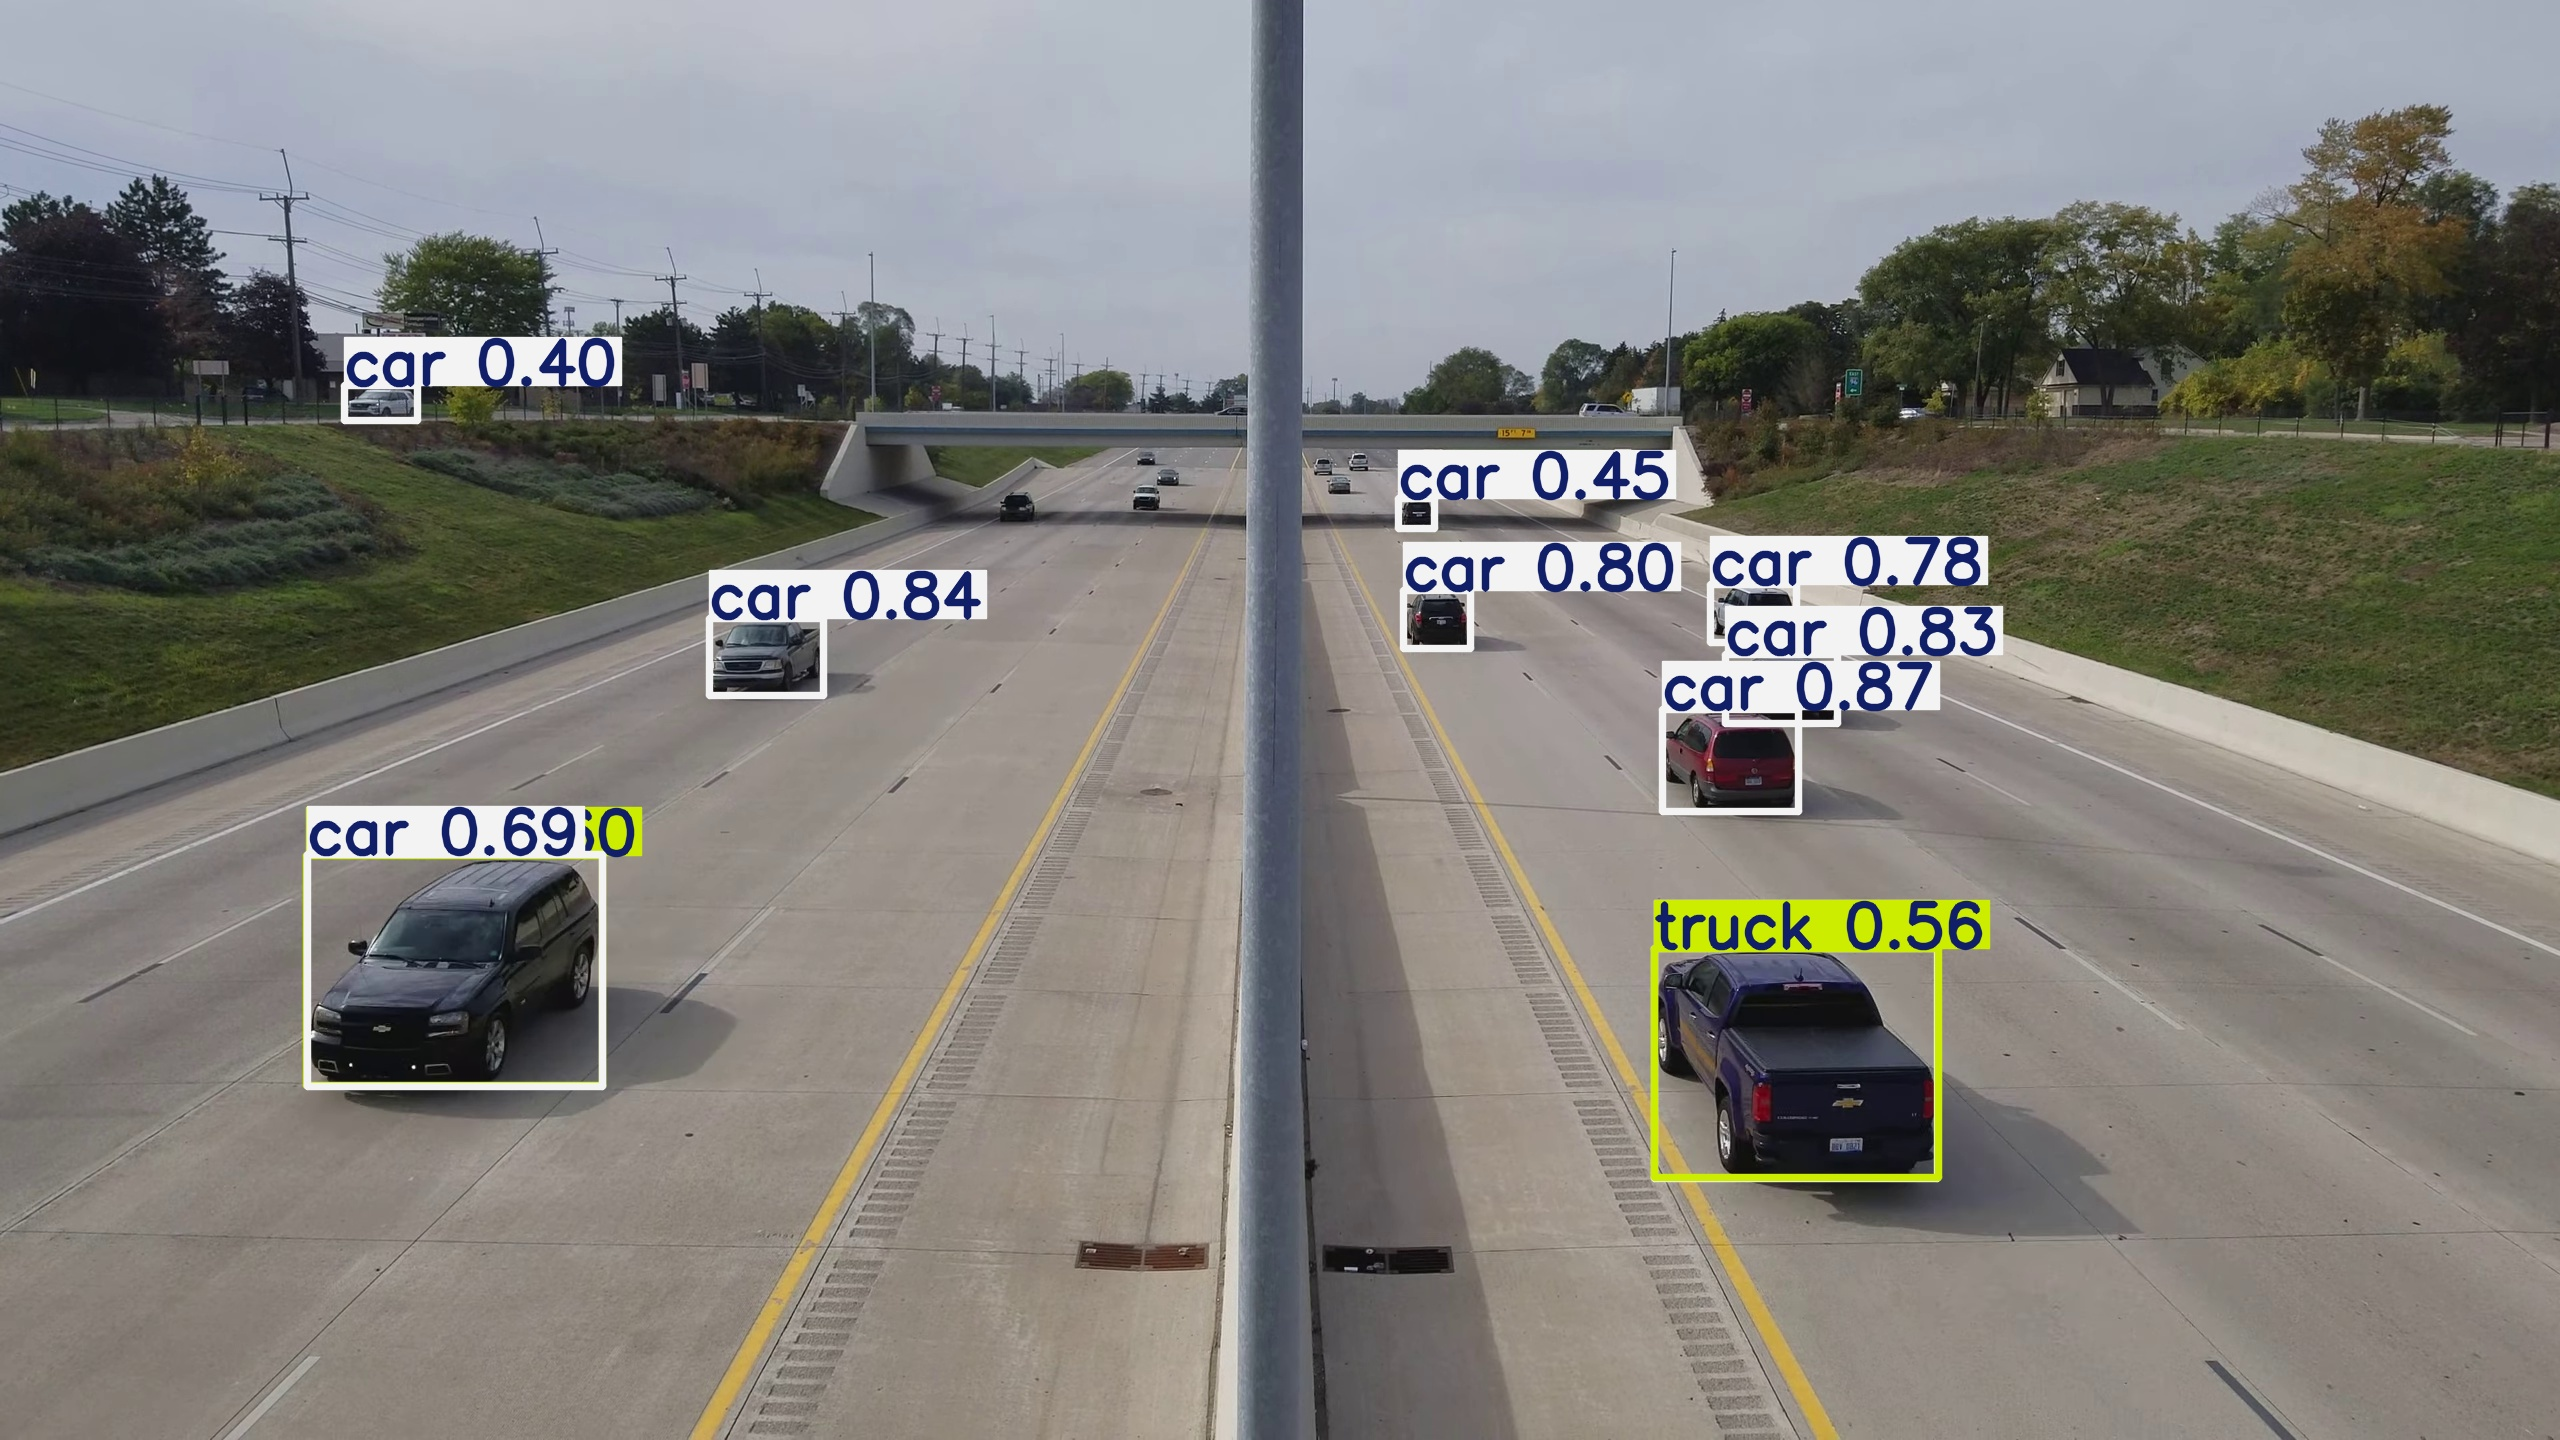

In [6]:
from IPython.display import Image, display

# Find the directory where the results were saved
# This assumes the latest run is the one named 'road_detection_yolov12l'
results_dir = os.path.join('runs', 'detect', 'road_detection_yolov12l')

# Get the path to the first saved image (or loop through all of them)
if os.path.exists(results_dir):
    saved_images = [f for f in os.listdir(results_dir) if f.endswith(('.jpg', '.png'))]
    if saved_images:
        print("\nDisplaying the first detected image:")
        first_image_path = os.path.join(results_dir, saved_images[0])
        display(Image(filename=first_image_path, width=600))
    else:
        print("No annotated images found in the results directory.")
else:
    print(f"Results directory not found: {results_dir}")